In [49]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, Dataset, DataLoader
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, classification_report, confusion_matrix,  accuracy_score, precision_recall_fscore_support,r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import shap
import os
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
import itertools
import torch.optim as optim
import seaborn as sns

In [50]:
#Bringing all the data into the dataframe

DATA_DIR = "unzipped_csvs/cleaned_dataset/data"
METADATA_PATH = "metadata.csv"

try:
    metadata = pd.read_csv(METADATA_PATH)
    print(f"Metadata loaded from {METADATA_PATH}")
except Exception as e:
    print(f"Error loading metadata: {e}")

all_data = []

for idx, row in metadata.iterrows():
    filename = row["filename"]
    filepath = os.path.join(DATA_DIR, filename)
    print(f"Opening {filename}...")

    try:
        df = pd.read_csv(filepath)
        for col in metadata.columns:
            df[col] = row[col]
        all_data.append(df)
    except Exception as e:
        print(f"Error reading {filename}: {e}")

if all_data:
    full_df = pd.concat(all_data, ignore_index=True)
else:
    print("No data was loaded.")


Metadata loaded from metadata.csv
Opening 00001.csv...
Opening 00002.csv...
Opening 00003.csv...
Opening 00004.csv...
Opening 00005.csv...
Opening 00006.csv...
Opening 00007.csv...
Opening 00008.csv...
Opening 00009.csv...
Opening 00010.csv...
Opening 00011.csv...
Opening 00012.csv...
Opening 00013.csv...
Opening 00014.csv...
Opening 00015.csv...
Opening 00016.csv...
Opening 00017.csv...
Opening 00018.csv...
Opening 00019.csv...
Opening 00020.csv...
Opening 00021.csv...
Opening 00022.csv...
Opening 00023.csv...
Opening 00024.csv...
Opening 00025.csv...
Opening 00026.csv...
Opening 00027.csv...
Opening 00028.csv...
Opening 00029.csv...
Opening 00030.csv...
Opening 00031.csv...
Opening 00032.csv...
Opening 00033.csv...
Opening 00034.csv...
Opening 00035.csv...
Opening 00036.csv...
Opening 00037.csv...
Opening 00038.csv...
Opening 00039.csv...
Opening 00040.csv...
Opening 00041.csv...
Opening 00042.csv...
Opening 00043.csv...
Opening 00044.csv...
Opening 00045.csv...
Opening 00046.csv...


Opening 00414.csv...
Opening 00415.csv...
Opening 00416.csv...
Opening 00417.csv...
Opening 00418.csv...
Opening 00419.csv...
Opening 00420.csv...
Opening 00421.csv...
Opening 00422.csv...
Opening 00423.csv...
Opening 00424.csv...
Opening 00425.csv...
Opening 00426.csv...
Opening 00427.csv...
Opening 00428.csv...
Opening 00429.csv...
Opening 00430.csv...
Opening 00431.csv...
Opening 00432.csv...
Opening 00433.csv...
Opening 00434.csv...
Opening 00435.csv...
Opening 00436.csv...
Opening 00437.csv...
Opening 00438.csv...
Opening 00439.csv...
Opening 00440.csv...
Opening 00441.csv...
Opening 00442.csv...
Opening 00443.csv...
Opening 00444.csv...
Opening 00445.csv...
Opening 00446.csv...
Opening 00447.csv...
Opening 00448.csv...
Opening 00449.csv...
Opening 00450.csv...
Opening 00451.csv...
Opening 00452.csv...
Opening 00453.csv...
Opening 00454.csv...
Opening 00455.csv...
Opening 00456.csv...
Opening 00457.csv...
Opening 00458.csv...
Opening 00459.csv...
Opening 00460.csv...
Opening 00461

Opening 00823.csv...
Opening 00824.csv...
Opening 00825.csv...
Opening 00826.csv...
Opening 00827.csv...
Opening 00828.csv...
Opening 00829.csv...
Opening 00830.csv...
Opening 00831.csv...
Opening 00832.csv...
Opening 00833.csv...
Opening 00834.csv...
Opening 00835.csv...
Opening 00836.csv...
Opening 00837.csv...
Opening 00838.csv...
Opening 00839.csv...
Opening 00840.csv...
Opening 00841.csv...
Opening 00842.csv...
Opening 00843.csv...
Opening 00844.csv...
Opening 00845.csv...
Opening 00846.csv...
Opening 00847.csv...
Opening 00848.csv...
Opening 00849.csv...
Opening 00850.csv...
Opening 00851.csv...
Opening 00852.csv...
Opening 00853.csv...
Opening 00854.csv...
Opening 00855.csv...
Opening 00856.csv...
Opening 00857.csv...
Opening 00858.csv...
Opening 00859.csv...
Opening 00860.csv...
Opening 00861.csv...
Opening 00862.csv...
Opening 00863.csv...
Opening 00864.csv...
Opening 00865.csv...
Opening 00866.csv...
Opening 00867.csv...
Opening 00868.csv...
Opening 00869.csv...
Opening 00870

Opening 01253.csv...
Opening 01254.csv...
Opening 01255.csv...
Opening 01256.csv...
Opening 01257.csv...
Opening 01258.csv...
Opening 01259.csv...
Opening 01260.csv...
Opening 01261.csv...
Opening 01262.csv...
Opening 01263.csv...
Opening 01264.csv...
Opening 01265.csv...
Opening 01266.csv...
Opening 01267.csv...
Opening 01268.csv...
Opening 01269.csv...
Opening 01270.csv...
Opening 01271.csv...
Opening 01272.csv...
Opening 01273.csv...
Opening 01274.csv...
Opening 01275.csv...
Opening 01276.csv...
Opening 01277.csv...
Opening 01278.csv...
Opening 01279.csv...
Opening 01280.csv...
Opening 01281.csv...
Opening 01282.csv...
Opening 01283.csv...
Opening 01284.csv...
Opening 01285.csv...
Opening 01286.csv...
Opening 01287.csv...
Opening 01288.csv...
Opening 01289.csv...
Opening 01290.csv...
Opening 01291.csv...
Opening 01292.csv...
Opening 01293.csv...
Opening 01294.csv...
Opening 01295.csv...
Opening 01296.csv...
Opening 01297.csv...
Opening 01298.csv...
Opening 01299.csv...
Opening 01300

Opening 01657.csv...
Opening 01658.csv...
Opening 01659.csv...
Opening 01660.csv...
Opening 01661.csv...
Opening 01662.csv...
Opening 01663.csv...
Opening 01664.csv...
Opening 01665.csv...
Opening 01666.csv...
Opening 01667.csv...
Opening 01668.csv...
Opening 01669.csv...
Opening 01670.csv...
Opening 01671.csv...
Opening 01672.csv...
Opening 01673.csv...
Opening 01674.csv...
Opening 01675.csv...
Opening 01676.csv...
Opening 01677.csv...
Opening 01678.csv...
Opening 01679.csv...
Opening 01680.csv...
Opening 01681.csv...
Opening 01682.csv...
Opening 01683.csv...
Opening 01684.csv...
Opening 01685.csv...
Opening 01686.csv...
Opening 01687.csv...
Opening 01688.csv...
Opening 01689.csv...
Opening 01690.csv...
Opening 01691.csv...
Opening 01692.csv...
Opening 01693.csv...
Opening 01694.csv...
Opening 01695.csv...
Opening 01696.csv...
Opening 01697.csv...
Opening 01698.csv...
Opening 01699.csv...
Opening 01700.csv...
Opening 01701.csv...
Opening 01702.csv...
Opening 01703.csv...
Opening 01704

...

Opening 05401.csv...
Opening 05402.csv...
Opening 05403.csv...
Opening 05404.csv...
Opening 05405.csv...
Opening 05406.csv...
Opening 05407.csv...
Opening 05408.csv...
Opening 05409.csv...
Opening 05410.csv...
Opening 05411.csv...
Opening 05412.csv...
Opening 05413.csv...
Opening 05414.csv...
Opening 05415.csv...
Opening 05416.csv...
Opening 05417.csv...
Opening 05418.csv...
Opening 05419.csv...
Opening 05420.csv...
Opening 05421.csv...
Opening 05422.csv...
Opening 05423.csv...
Opening 05424.csv...
Opening 05425.csv...
Opening 05426.csv...
Opening 05427.csv...
Opening 05428.csv...
Opening 05429.csv...
Opening 05430.csv...
Opening 05431.csv...
Opening 05432.csv...
Opening 05433.csv...
Opening 05434.csv...
Opening 05435.csv...
Opening 05436.csv...
Opening 05437.csv...
Opening 05438.csv...
Opening 05439.csv...
Opening 05440.csv...
Opening 05441.csv...
Opening 05442.csv...
Opening 05443.csv...
Opening 05444.csv...
Opening 05445.csv...
Opening 05446.csv...
Opening 05447.csv...
Opening 05448

Opening 05805.csv...
Opening 05806.csv...
Opening 05807.csv...
Opening 05808.csv...
Opening 05809.csv...
Opening 05810.csv...
Opening 05811.csv...
Opening 05812.csv...
Opening 05813.csv...
Opening 05814.csv...
Opening 05815.csv...
Opening 05816.csv...
Opening 05817.csv...
Opening 05818.csv...
Opening 05819.csv...
Opening 05820.csv...
Opening 05821.csv...
Opening 05822.csv...
Opening 05823.csv...
Opening 05824.csv...
Opening 05825.csv...
Opening 05826.csv...
Opening 05827.csv...
Opening 05828.csv...
Opening 05829.csv...
Opening 05830.csv...
Opening 05831.csv...
Opening 05832.csv...
Opening 05833.csv...
Opening 05834.csv...
Opening 05835.csv...
Opening 05836.csv...
Opening 05837.csv...
Opening 05838.csv...
Opening 05839.csv...
Opening 05840.csv...
Opening 05841.csv...
Opening 05842.csv...
Opening 05843.csv...
Opening 05844.csv...
Opening 05845.csv...
Opening 05846.csv...
Opening 05847.csv...
Opening 05848.csv...
Opening 05849.csv...
Opening 05850.csv...
Opening 05851.csv...
Opening 05852

Opening 06256.csv...
Opening 06257.csv...
Opening 06258.csv...
Opening 06259.csv...
Opening 06260.csv...
Opening 06261.csv...
Opening 06262.csv...
Opening 06263.csv...
Opening 06264.csv...
Opening 06265.csv...
Opening 06266.csv...
Opening 06267.csv...
Opening 06268.csv...
Opening 06269.csv...
Opening 06270.csv...
Opening 06271.csv...
Opening 06272.csv...
Opening 06273.csv...
Opening 06274.csv...
Opening 06275.csv...
Opening 06276.csv...
Opening 06277.csv...
Opening 06278.csv...
Opening 06279.csv...
Opening 06280.csv...
Opening 06281.csv...
Opening 06282.csv...
Opening 06283.csv...
Opening 06284.csv...
Opening 06285.csv...
Opening 06286.csv...
Opening 06287.csv...
Opening 06288.csv...
Opening 06289.csv...
Opening 06290.csv...
Opening 06291.csv...
Opening 06292.csv...
Opening 06293.csv...
Opening 06294.csv...
Opening 06295.csv...
Opening 06296.csv...
Opening 06297.csv...
Opening 06298.csv...
Opening 06299.csv...
Opening 06300.csv...
Opening 06301.csv...
Opening 06302.csv...
Opening 06303

Opening 06739.csv...
Opening 06740.csv...
Opening 06741.csv...
Opening 06742.csv...
Opening 06743.csv...
Opening 06744.csv...
Opening 06745.csv...
Opening 06746.csv...
Opening 06747.csv...
Opening 06748.csv...
Opening 06749.csv...
Opening 06750.csv...
Opening 06751.csv...
Opening 06752.csv...
Opening 06753.csv...
Opening 06754.csv...
Opening 06755.csv...
Opening 06756.csv...
Opening 06757.csv...
Opening 06758.csv...
Opening 06759.csv...
Opening 06760.csv...
Opening 06761.csv...
Opening 06762.csv...
Opening 06763.csv...
Opening 06764.csv...
Opening 06765.csv...
Opening 06766.csv...
Opening 06767.csv...
Opening 06768.csv...
Opening 06769.csv...
Opening 06770.csv...
Opening 06771.csv...
Opening 06772.csv...
Opening 06773.csv...
Opening 06774.csv...
Opening 06775.csv...
Opening 06776.csv...
Opening 06777.csv...
Opening 06778.csv...
Opening 06779.csv...
Opening 06780.csv...
Opening 06781.csv...
Opening 06782.csv...
Opening 06783.csv...
Opening 06784.csv...
Opening 06785.csv...
Opening 06786

Opening 07198.csv...
Opening 07199.csv...
Opening 07200.csv...
Opening 07201.csv...
Opening 07202.csv...
Opening 07203.csv...
Opening 07204.csv...
Opening 07205.csv...
Opening 07206.csv...
Opening 07207.csv...
Opening 07208.csv...
Opening 07209.csv...
Opening 07210.csv...
Opening 07211.csv...
Opening 07212.csv...
Opening 07213.csv...
Opening 07214.csv...
Opening 07215.csv...
Opening 07216.csv...
Opening 07217.csv...
Opening 07218.csv...
Opening 07219.csv...
Opening 07220.csv...
Opening 07221.csv...
Opening 07222.csv...
Opening 07223.csv...
Opening 07224.csv...
Opening 07225.csv...
Opening 07226.csv...
Opening 07227.csv...
Opening 07228.csv...
Opening 07229.csv...
Opening 07230.csv...
Opening 07231.csv...
Opening 07232.csv...
Opening 07233.csv...
Opening 07234.csv...
Opening 07235.csv...
Opening 07236.csv...
Opening 07237.csv...
Opening 07238.csv...
Opening 07239.csv...
Opening 07240.csv...
Opening 07241.csv...
Opening 07242.csv...
Opening 07243.csv...
Opening 07244.csv...
Opening 07245

In [97]:
#Uses Regex to extract 00001 to 1, etc, capturing the digits, and drop leading zeros for cycle index
full_df["cycle_index"] = (full_df.filename.str.extract(r"^0*(\d+)\.csv$", expand=False).astype(int))
full_df.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time,type,start_time,ambient_temperature,battery_id,...,Rct,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance,Current_charge,Voltage_charge,cycle_index,cycle
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1


In [53]:
#Creates a local cycle counter for each battery
full_df["cycle"] = (full_df["cycle_index"] - full_df.groupby("battery_id")["cycle_index"].transform("min") + 1)

#Check the new cycle numbers
unique = (full_df[["battery_id","cycle"]].drop_duplicates().groupby("battery_id")["cycle"].agg(["min","max","count"]).sort_index())
print(unique)

            min  max  count
battery_id                 
B0005         1  616    616
B0006         1  616    616
B0007         1  616    616
B0018         1  319    319
B0025         1   80     80
B0026         1   80     80
B0027         1   80     80
B0028         1   80     80
B0029         1   97     97
B0030         1   97     97
B0031         1   97     97
B0032         1   97     97
B0033         1  486    486
B0034         1  486    486
B0036         1  486    486
B0038         1  122    122
B0039         1  122    122
B0040         1  122    122
B0041         1  163    163
B0042         1  275    275
B0043         1  275    275
B0044         1  275    275
B0045         1  184    184
B0046         1  184    184
B0047         1  184    184
B0048         1  184    184
B0049         1   62     62
B0050         1   62     62
B0051         1   62     62
B0052         1   62     62
B0053         1  137    137
B0054         1  253    253
B0055         1  252    252
B0056         1  252

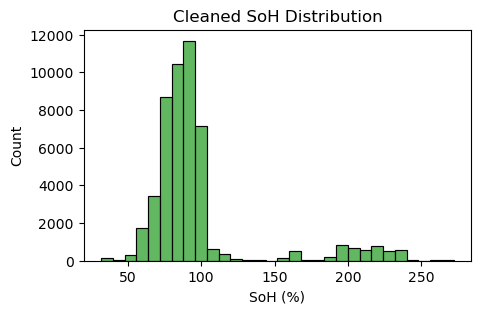

In [109]:
MIN_VALID_Q=0.5
N_PROBE_CYCLES=5
battery_caps={}
for bid,df_batt in full_df.groupby("battery_id"):
    q_list=[]
    for cyc in range(1,N_PROBE_CYCLES+1):
        d=df_batt[(df_batt["cycle"]==cyc)&(df_batt["Current_measured"]<0)].sort_values("Time")
        if d.empty: continue
        cut=d[d["Voltage_measured"]<2.7].index
        if len(cut): d=d.loc[:cut.min()]
        dt_hr=d["Time"].diff().fillna(0)/3600.0
        q_ah=-(d["Current_measured"]*dt_hr).sum()
        if q_ah>=MIN_VALID_Q: q_list.append(q_ah)
    if q_list: battery_caps[bid]=max(q_list)

records=[]
for (bid,cyc),df_c in full_df.groupby(["battery_id","cycle"]):
    q_nom=battery_caps.get(bid)
    if q_nom is None: continue
    d=df_c[df_c["Current_measured"]<0].sort_values("Time")
    
    if d.empty: continue
    cut=d[d["Voltage_measured"]<2.7].index
    
    if len(cut): d=d.loc[:cut.min()]
    dt_hr=d["Time"].diff().fillna(0)/3600.0
    d["dQ"]=-(d["Current_measured"]*dt_hr)
    d["Qcum"]=d["dQ"].cumsum()
    q_cycle=d["dQ"].sum()
    
    if q_cycle<MIN_VALID_Q: continue
    soh=100*q_cycle/q_nom
    d["SoC"]=100*d["Qcum"]/q_cycle
    soc_grid=np.linspace(0,100,20)
    interp=lambda col: np.interp(soc_grid,d["SoC"],d[col])
    amb_temp=df_c["ambient_temperature"].iloc[0]
    df_out=pd.DataFrame({"SoC":soc_grid.clip(0,100), "Voltage_measured":interp("Voltage_measured"),
        "Current_measured":interp("Current_measured"), "Temperature_measured":interp("Temperature_measured"),
        "ambient_temperature":amb_temp, "SoH":soh})
    df_out["battery_id"]=bid
    df_out["cycle"]=cyc
    records.append(df_out)

battery_health=pd.concat(records,ignore_index=True)
plt.figure(figsize=(5,3))
sns.histplot(battery_health["SoH"],bins=30,color="C2",edgecolor="black")
plt.title("Cleaned SoH Distribution")
plt.xlabel("SoH (%)")
plt.show()

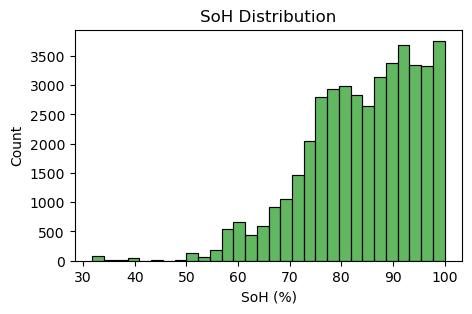

In [110]:
battery_health = battery_health[battery_health["SoH"] <= 100.0]

plt.figure(figsize=(5,3))
sns.histplot(battery_health["SoH"], bins=30, color="C2")
plt.title("SoH Distribution")
plt.xlabel("SoH (%)"); plt.show()

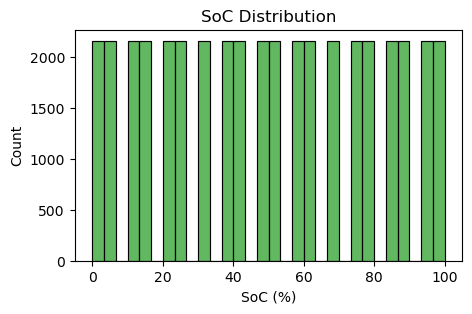

In [111]:
plt.figure(figsize=(5,3))
sns.histplot(battery_health["SoC"], bins=30, color="C2")
plt.title("SoC Distribution")
plt.xlabel("SoC (%)"); plt.show()

Epoch 01 | Train MAE: 27.00% | Val MAE: 10.85% | LR: 5.0e-04
Epoch 10 | Train MAE: 4.90% | Val MAE: 7.22% | LR: 5.0e-04
Epoch 20 | Train MAE: 3.79% | Val MAE: 5.19% | LR: 2.5e-04
Epoch 30 | Train MAE: 3.40% | Val MAE: 5.08% | LR: 1.3e-04
Epoch 40 | Train MAE: 3.39% | Val MAE: 4.91% | LR: 6.3e-05
Epoch 50 | Train MAE: 2.99% | Val MAE: 4.85% | LR: 3.1e-05
Epoch 60 | Train MAE: 2.94% | Val MAE: 5.06% | LR: 7.8e-06


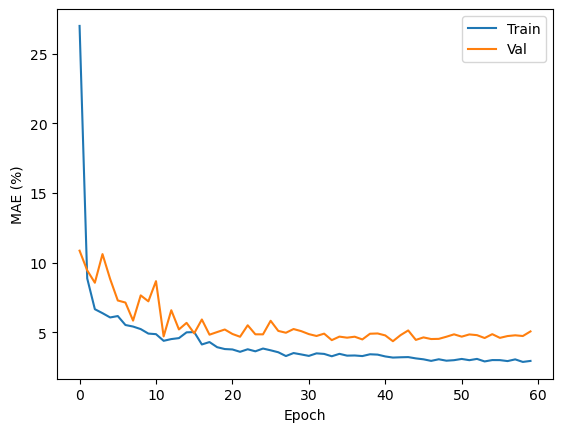

Final Val MAE: 5.06%


In [115]:
#Train CNNRegressor with Battery‐Grouped Split 

feature_cols = ['Voltage_measured','Current_measured','Temperature_measured','SoC','ambient_temperature']
X_list, y_list, batt_ids = [], [], []

for (bid, cyc), grp in battery_health.groupby(['battery_id','cycle']):
    X_list.append(grp[feature_cols].values.T.astype(np.float32))
    y_list.append(grp['SoH'].iloc[0] / 100.0)
    batt_ids.append(bid)

X = np.stack(X_list)                     
y = np.array(y_list, dtype=np.float32)   
batt_ids = np.array(batt_ids)

#Group‐wise split for no battery leakage
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups=batt_ids))
X_tr, X_val = X[train_idx], X[val_idx]
y_tr, y_val = y[train_idx], y[val_idx]

#normalize train data
means = X_tr.mean(axis=(0,2), keepdims=True)
stds = X_tr.std(axis=(0,2), keepdims=True)
X_tr = (X_tr - means) / (stds + 1e-6)
X_val = (X_val - means) / (stds + 1e-6)

#Dataloaders
train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
val_ds = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)

class CNNRegressor(nn.Module):
    def __init__(self, in_ch=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_ch, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(64,128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128,256,kernel_size=3,padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Linear(256,1)

    def forward(self,x):
        x = self.features(x).squeeze(-1)
        return self.head(x).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNRegressor().to(device)
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
criterion = nn.L1Loss() 

train_maes, val_maes = [], []
for epoch in range(60):
    model.train()
    train_acc = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_acc += loss.item() * xb.size(0)
    train_mae = train_acc / len(train_loader.dataset)
    train_maes.append(train_mae)

    model.eval()
    val_acc = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_acc += criterion(model(xb), yb).item() * xb.size(0)
    val_mae = val_acc / len(val_loader.dataset)
    val_maes.append(val_mae)

    scheduler.step(val_mae)
    if epoch==1 or epoch%10==0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:02d} | Train MAE: {train_mae*100:.2f}% | Val MAE: {val_mae*100:.2f}% | LR: {lr:.1e}")

plt.plot(np.array(train_maes)*100, label="Train")
plt.plot(np.array(val_maes)*100, label="Val")
plt.xlabel("Epoch"); plt.ylabel("MAE (%)"); plt.legend(); plt.show()

model.eval()
with torch.no_grad():
    y_pred = model(torch.tensor(X_val).to(device)).cpu().numpy()*100
y_true = y_val*100
print("Final Val MAE: %.2f%%" % (np.mean(np.abs(y_pred - y_true))))


Scatter MAE: 5.06%


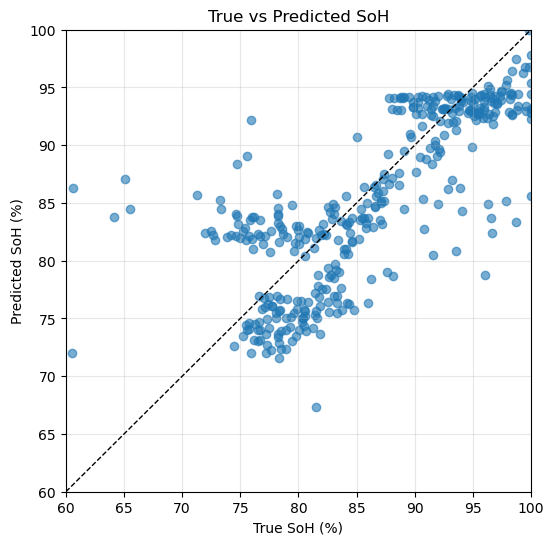

In [116]:
#Plotting Predicted vs Actual SoH 

#Recover SoH in %
y_true = y_val * 100
mae = np.mean(np.abs(y_pred - y_true))
print(f"Scatter MAE: {mae:.2f}%")

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6)
lims = [max(60, min(y_true.min(), y_pred.min())),min(100, max(y_true.max(), y_pred.max()))]
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlabel("True SoH (%)")
plt.ylabel("Predicted SoH (%)")
plt.title("True vs Predicted SoH")
plt.xlim(60, 100)
plt.ylim(60, 100)
plt.grid(alpha=0.3)
plt.show()

,lr,weight_decay,dropout,val_mae
0,0.0010,0.00010,0.1,0.049022
1,0.0010,0.00010,0.3,0.084551
2,0.0010,0.00001,0.1,0.095687
3,0.0010,0.00001,0.3,0.083280
4,0.0005,0.00010,0.1,0.075229
5,0.0005,0.00010,0.3,0.054188
6,0.0005,0.00001,0.1,0.059246
7,0.0005,0.00001,0.3,0.056503
8,0.0001,0.00010,0.1,0.068892
9,0.0001,0.00010,0.3,0.080041


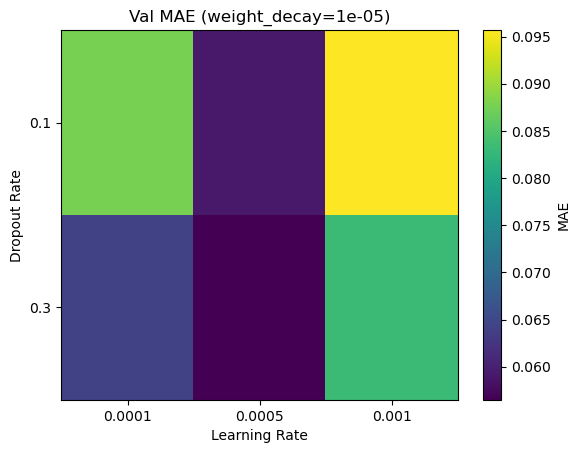

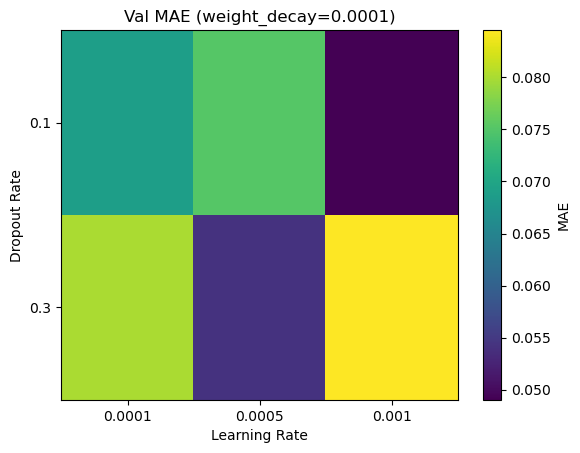

In [120]:
#Grid Search Parameter Ranges
lrs = [1e-3, 5e-4, 1e-4]
wds = [1e-4, 1e-5]
drops = [0.1, 0.3]
grid = list(itertools.product(lrs, wds, drops))

class CNNRegSearch(nn.Module):
    def __init__(self, in_ch=5, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch,64,3,padding=1), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(64,128,3,padding=1), nn.BatchNorm1d(128), nn.ReLU(), nn.AdaptiveAvgPool1d(1),
            nn.Flatten(), nn.Linear(128,1) 
        )
    def forward(self,x):
        return self.net(x).squeeze(-1)

results = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.L1Loss() #MAE

for lr, wd, dr in grid:
    model = CNNRegSearch(dropout=dr).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    for epoch in range(20):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds.append(model(xb).cpu().numpy())
            trues.append(yb.cpu().numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    mae = mean_absolute_error(trues, preds)

    results.append({'lr': lr,'weight_decay': wd,'dropout': dr,'val_mae': mae})

df = pd.DataFrame(results)
display(df)

#Heatmaps
for wd in sorted(df.weight_decay.unique()):
    sub = df[df.weight_decay == wd]
    pivot = sub.pivot(index='dropout', columns='lr', values='val_mae')
    plt.figure()
    plt.imshow(pivot, aspect='auto')
    plt.title(f"Val MAE (weight_decay={wd})")
    plt.xlabel("Learning Rate")
    plt.ylabel("Dropout Rate")
    plt.xticks(np.arange(len(pivot.columns)), pivot.columns)
    plt.yticks(np.arange(len(pivot.index)), pivot.index)
    plt.colorbar(label="MAE")
    plt.show()


Architecture + Scheduler Grid Search Results:



,depth,width,kernel,val_mae
0,2,64,3,0.066602
1,2,64,5,0.066819
2,2,128,3,0.056290
3,2,128,5,0.077596
4,3,64,3,0.078952
5,3,64,5,0.065982
6,3,128,3,0.068214
7,3,128,5,0.064841


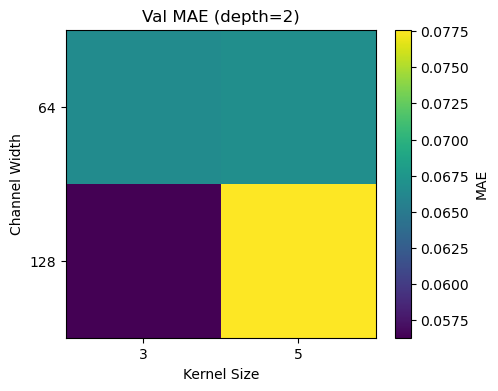

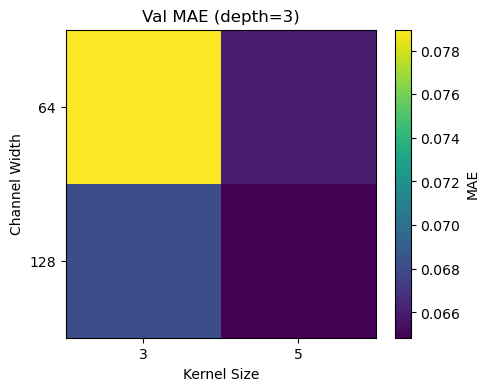

In [122]:
#Architecture & Scheduler Grid Search
depths = [2, 3]
widths = [64, 128]
kernels = [3, 5]
param_grid = list(itertools.product(depths, widths, kernels))

class CNNParam(nn.Module):
    def __init__(self, in_ch=5, depth=2, width=64, kernel=3, dropout=0.2):
        super().__init__()
        layers = []
        ch = in_ch
        for _ in range(depth):
            layers += [
                nn.Conv1d(ch, width, kernel_size=kernel, padding=kernel//2),
                nn.BatchNorm1d(width),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            ch = width
        layers += [nn.AdaptiveAvgPool1d(1), nn.Flatten()]
        self.features = nn.Sequential(*layers)
        self.regressor = nn.Sequential(nn.Linear(width, 1))
    def forward(self, x):
        x = self.features(x)
        return self.regressor(x).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.L1Loss()  
num_epochs = 20
results = []

for depth, width, kernel in param_grid:
    model = CNNParam(depth=depth, width=width, kernel=kernel).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer,max_lr=5e-4,steps_per_epoch=len(train_loader),epochs=num_epochs)

    for epoch in range(num_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            scheduler.step()
            
    model.eval()
    val_preds, val_trues = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_preds.append(model(xb).cpu().numpy())
            val_trues.append(yb.cpu().numpy())
    val_preds = np.concatenate(val_preds)
    val_trues = np.concatenate(val_trues)
    mae = mean_absolute_error(val_trues, val_preds)
    results.append({'depth': depth,'width': width,'kernel': kernel,'val_mae': mae})

df_results = pd.DataFrame(results)
print("\nArchitecture + Scheduler Grid Search Results:\n")
display(df_results)

#Heatmaps
for depth in depths:
    sub = df_results[df_results['depth'] == depth]
    pivot = sub.pivot(index='width', columns='kernel', values='val_mae')
    plt.figure(figsize=(5,4))
    plt.imshow(pivot, aspect='auto')
    plt.title(f"Val MAE (depth={depth})")
    plt.xlabel("Kernel Size")
    plt.ylabel("Channel Width")
    plt.xticks(np.arange(len(pivot.columns)), pivot.columns)
    plt.yticks(np.arange(len(pivot.index)), pivot.index)
    plt.colorbar(label="MAE")
    plt.show()

Epoch 01 | Train MAE: 13.86% | Val MAE: 6.28% | LR: 1.0e-03
Epoch 10 | Train MAE: 3.90% | Val MAE: 5.07% | LR: 1.0e-03
Epoch 20 | Train MAE: 3.23% | Val MAE: 5.16% | LR: 5.0e-04
Epoch 30 | Train MAE: 2.90% | Val MAE: 4.87% | LR: 2.5e-04
Epoch 40 | Train MAE: 2.99% | Val MAE: 4.41% | LR: 1.3e-04
Epoch 50 | Train MAE: 2.71% | Val MAE: 3.97% | LR: 6.3e-05


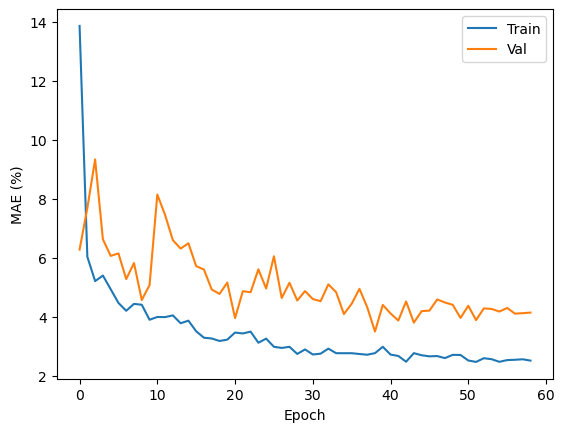

Final Val MAE: 3.51%


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


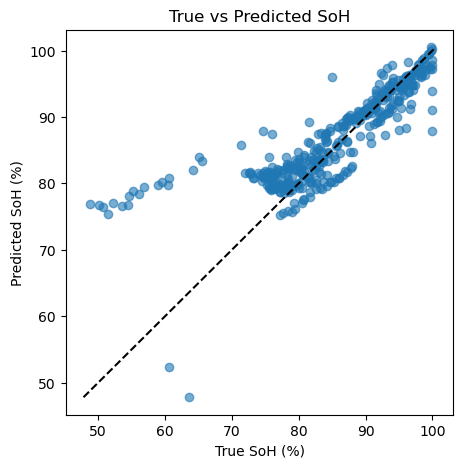

In [124]:
feature_cols = [c for c in battery_health.columns if c not in ['battery_id','cycle','SoH']]

# build arrays
X_list, y_list, groups = [], [], []
for (bid, cyc), grp in battery_health.groupby(['battery_id','cycle']):
    X_list.append(grp[feature_cols].values.T.astype(np.float32))
    y_list.append(grp['SoH'].iloc[0] / 100.0)
    groups.append(bid)
X = np.stack(X_list)
y = np.array(y_list, dtype=np.float32)
groups = np.array(groups)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, va_idx = next(gss.split(X, y, groups=groups))
X_tr, X_va = X[tr_idx], X[va_idx]
y_tr, y_va = y[tr_idx], y[va_idx]

mu, sd = X_tr.mean((0,2), keepdims=True), X_tr.std((0,2), keepdims=True)
X_tr = (X_tr - mu) / (sd + 1e-6)
X_va = (X_va - mu) / (sd + 1e-6)

train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
val_ds = TensorDataset(torch.tensor(X_va), torch.tensor(y_va))
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)

class CNNRegressor(nn.Module):
    def __init__(self, in_ch, depth=2, width=64, kernel=3, p=0.1):
        super().__init__()
        layers, ch = [], in_ch
        for i in range(depth):
            layers += [
                nn.Conv1d(ch, width, kernel_size=kernel, padding=kernel//2),
                nn.BatchNorm1d(width),
                nn.ReLU()
            ]
            if i < depth - 1:
                layers.append(nn.Dropout(p))
            ch = width
        layers.append(nn.AdaptiveAvgPool1d(1))
        self.features = nn.Sequential(*layers)
        self.head = nn.Linear(width, 1)

    def forward(self, x):
        x = self.features(x).squeeze(-1)
        return self.head(x).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNRegressor(len(feature_cols)).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
criterion = nn.L1Loss() 

#early stopping
best_val = 1e9
no_imp = 0
train_maes, val_maes = [], []

for epoch in range(50):
    # train
    model.train()
    acc = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        acc += loss.item() * xb.size(0)
    train_mae = acc / len(train_loader.dataset)
    train_maes.append(train_mae)

    model.eval()
    acc = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            acc += criterion(model(xb), yb).item() * xb.size(0)
    val_mae = acc / len(val_loader.dataset)
    val_maes.append(val_mae)
    scheduler.step(val_mae)

    if val_mae < best_val - 1e-4:
        best_val = val_mae
        no_imp = 0
        torch.save(model.state_dict(), "best_soh_model.pt")
    else:
        no_imp += 1
        if no_imp >= 20:
            break

    if epoch == 1 or epoch % 10 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:02d} | Train MAE: {train_mae*100:.2f}% | Val MAE: {val_mae*100:.2f}% | LR: {lr:.1e}")

plt.plot(np.array(train_maes)*100, label="Train")
plt.plot(np.array(val_maes)*100, label="Val")
plt.xlabel("Epoch"); plt.ylabel("MAE (%)"); plt.legend(); plt.show()

model.load_state_dict(torch.load("best_soh_model.pt"))
model.eval()
with torch.no_grad():
    y_pred = model(torch.tensor(X_va).to(device)).cpu().numpy() * 100
y_true = y_va * 100

final_mae = mean_absolute_error(y_true, y_pred)
print(f"Final Val MAE: {final_mae:.2f}%")

plt.figure(figsize=(5,5))
plt.scatter(y_true, y_pred, alpha=0.6)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'k--')
plt.xlabel("True SoH (%)")
plt.ylabel("Predicted SoH (%)")
plt.title("True vs Predicted SoH")
plt.show()

Epoch 01 | Train MAE: 1.09% | Val MAE: 11.10%
Epoch 10 | Train MAE: 0.27% | Val MAE: 6.26%
Epoch 20 | Train MAE: 0.18% | Val MAE: 7.94%
Epoch 30 | Train MAE: 0.15% | Val MAE: 5.23%
Epoch 40 | Train MAE: 0.16% | Val MAE: 4.67%
Epoch 50 | Train MAE: 0.15% | Val MAE: 4.76%
Epoch 60 | Train MAE: 0.15% | Val MAE: 4.80%


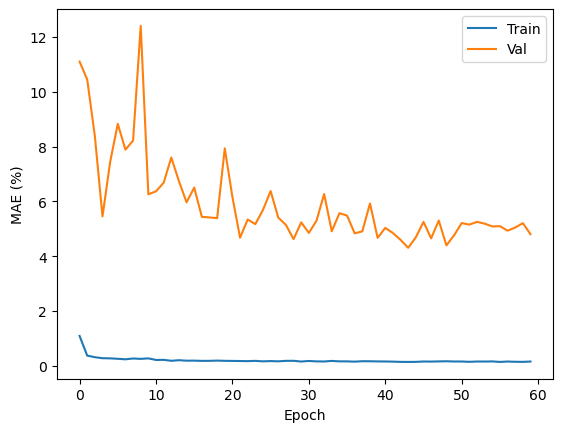

Final Val MAE: 4.80%


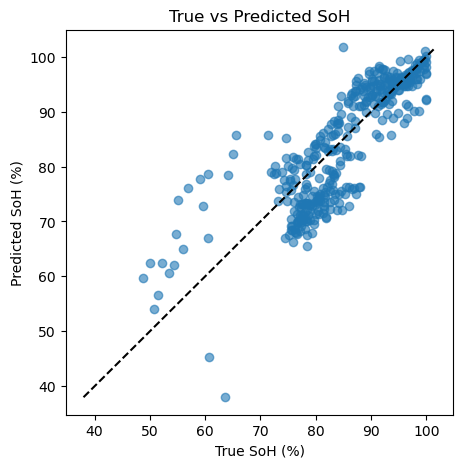

In [130]:
#CNN using inverse-sqrt bin weighting to try and improve lower SoH predictions

#normalized cycle index
if "cycle_norm" not in battery_health.columns:
    eol = full_df.groupby("battery_id")["cycle"].max().rename("eol_cycle")
    battery_health = battery_health.merge(eol, on="battery_id")
    battery_health["cycle_norm"] = battery_health["cycle"] / battery_health["eol_cycle"]

features = ["Voltage_measured","Current_measured","Temperature_measured", "SoC","ambient_temperature","cycle_norm"]
X_list, y_list, groups = [], [], []
for (bid, cyc), grp in battery_health.groupby(["battery_id","cycle"]):
    X_list.append(grp[features].values.T.astype(np.float32))
    y_list.append(grp["SoH"].iloc[0] / 100.0)
    groups.append(bid)
X = np.stack(X_list)
y = np.array(y_list, dtype=np.float32)
groups = np.array(groups)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, va_idx = next(gss.split(X, y, groups=groups))
X_tr, X_va = X[tr_idx], X[va_idx]
y_tr, y_va = y[tr_idx], y[va_idx]

mu, sd = X_tr.mean((0,2), keepdims=True), X_tr.std((0,2), keepdims=True)
X_tr = (X_tr - mu) / (sd + 1e-6)
X_va = (X_va - mu) / (sd + 1e-6)

train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
val_ds = TensorDataset(torch.tensor(X_va), torch.tensor(y_va))

#compute inverse-sqrt bin weights for SoH distribution
n_bins = 5
bin_ids = np.digitize(y_tr, np.linspace(0,1,n_bins+1)) - 1
counts = np.bincount(bin_ids, minlength=n_bins)
bin_weights = 1.0 / np.sqrt(counts + 1e-6)
sample_weights = bin_weights[bin_ids]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

#same parameters as before
class CNNRegressor(nn.Module):
    def __init__(self, in_ch=6, depth=2, width=64, kernel=3, dropout=0.1):
        super().__init__()
        layers, ch = [], in_ch
        for i in range(depth):
            layers += [
                nn.Conv1d(ch, width, kernel, padding=kernel//2),
                nn.BatchNorm1d(width),
                nn.ReLU()
            ]
            if i < depth-1:
                layers.append(nn.Dropout(dropout))
            ch = width
        layers.append(nn.AdaptiveAvgPool1d(1))
        self.features = nn.Sequential(*layers)
        self.head = nn.Linear(width, 1)

    def forward(self, x):
        x = self.features(x).squeeze(-1)
        return self.head(x).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNRegressor().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5)
criterion = nn.L1Loss()
train_mae, val_mae = [], []

for epoch in range(60):
    model.train()
    total, count = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = (torch.abs(model(xb) - yb) * torch.tensor(bin_weights[bin_ids][count:count+xb.size(0)], device=device)).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item() * xb.size(0)
        count += xb.size(0)
    train_mae.append(total / count)

    model.eval()
    total, count = 0.0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            total += torch.abs(model(xb) - yb).sum().item()
            count += xb.size(0)
    val_mae.append(total / count)
    scheduler.step(val_mae[-1])

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:02d} | Train MAE: {train_mae[-1]*100:.2f}% | Val MAE: {val_mae[-1]*100:.2f}%")

plt.plot(np.array(train_mae)*100, label="Train")
plt.plot(np.array(val_mae)*100, label="Val")
plt.xlabel("Epoch")
plt.ylabel("MAE (%)")
plt.legend()
plt.show()
model.eval()
with torch.no_grad():
    y_pred = model(torch.tensor(X_va).to(device)).cpu().numpy() * 100
y_true = y_va * 100
print("Final Val MAE: {:.2f}%".format(mean_absolute_error(y_true, y_pred)))
plt.figure(figsize=(5,5))
plt.scatter(y_true, y_pred, alpha=0.6)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'k--')
plt.xlabel("True SoH (%)")
plt.ylabel("Predicted SoH (%)")
plt.title("True vs Predicted SoH")
plt.show()

In [157]:
#Preparing RUL df

eol = full_df.groupby("battery_id")["cycle"].max().rename("eol_cycle") #end of life per battery

# collapse each battery and cycle to one row of summary stats + RUL
records = []
for (bid, cyc), grp in full_df.groupby(["battery_id","cycle"]):
    records.append({"battery_id": bid,"cycle": cyc,"rul": eol.loc[bid] - cyc,"volt_mean": grp.Voltage_measured.mean(),
        "volt_std": grp.Voltage_measured.std(),"curr_mean": grp.Current_measured.mean(),"curr_std": grp.Current_measured.std(),
        "temp_mean": grp.Temperature_measured.mean(),"temp_std": grp.Temperature_measured.std()})
df_rul = pd.DataFrame(records)

df_soh = (battery_health.drop_duplicates(["battery_id","cycle"]).loc[:,["battery_id","cycle","SoH"]].rename(columns={"SoH":"SoH_pct"}))
df_rul = df_rul.merge(df_soh, on=["battery_id","cycle"], how="left")
df_rul = df_rul.dropna(subset=["SoH_pct"]).reset_index(drop=True)
df_rul["eol_cycle"]  = df_rul.groupby("battery_id")["cycle"].transform("max")
df_rul["cycle_frac"] = df_rul["cycle"] / df_rul["eol_cycle"]

feature_cols_ext = ["volt_mean","volt_std","curr_mean","curr_std","temp_mean","temp_std","cycle_frac","SoH_pct"]
X = df_rul[feature_cols_ext].values.astype(np.float32)
y = df_rul["rul"].values.astype(np.float32)


In [158]:
#Group Split, Standard Scaler and DataLoaders

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df_rul["battery_id"]))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
X_val, X_te, y_val, y_te = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_te = scaler.transform(X_te)

def make_loader(X, y, bs=32, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, bs=32, shuffle=True)
val_loader = make_loader(X_val, y_val, bs=64, shuffle=False)
test_loader = make_loader(X_te, y_te, bs=64, shuffle=False)

Epoch 00 | Train MAE: 194.3458 | Val MAE: 105.5148
Epoch 10 | Train MAE: 67.6468 | Val MAE: 74.1659
Epoch 20 | Train MAE: 54.7477 | Val MAE: 62.8609
Epoch 30 | Train MAE: 49.0739 | Val MAE: 58.8728
Epoch 40 | Train MAE: 45.4300 | Val MAE: 57.1412
Epoch 50 | Train MAE: 43.9604 | Val MAE: 56.1603


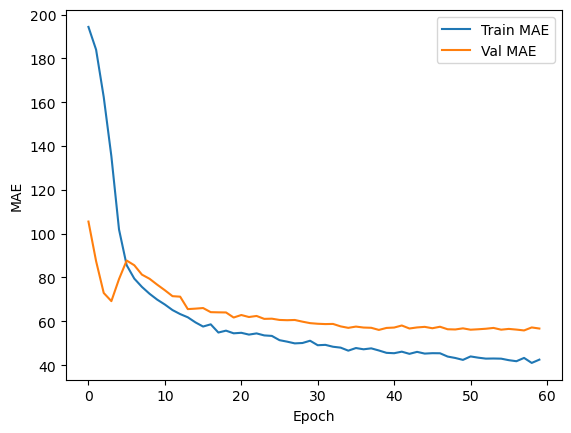

Extended RUL Test MAE: 55.39 cycles (52.86%)


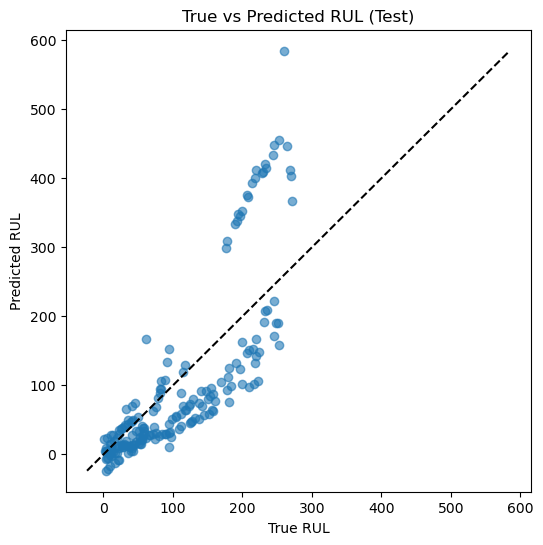

In [172]:
class RULExtRegressor(nn.Module):
    def __init__(self, in_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ext = RULExtRegressor(len(feature_cols_ext), 128).to(device)
opt_ext = optim.AdamW(model_ext.parameters(), lr=5e-4, weight_decay=1e-4)
criterion = nn.L1Loss()

train_mae, val_mae = [], []
for ep in range(60):
    model_ext.train()
    tot = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt_ext.zero_grad()
        loss = criterion(model_ext(xb), yb)
        loss.backward()
        opt_ext.step()
        tot += loss.item() * xb.size(0)
    train_mae.append(tot / len(train_loader.dataset))

    model_ext.eval()
    tot = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            tot += criterion(model_ext(xb), yb).item() * xb.size(0)
    val_mae.append(tot / len(val_loader.dataset))

    if ep % 10 == 0:
        print(f"Epoch {ep:02d} | Train MAE: {train_mae[-1]:.4f} | Val MAE: {val_mae[-1]:.4f}")

plt.plot(train_mae, label="Train MAE")
plt.plot(val_mae, label="Val MAE")
plt.xlabel("Epoch"); plt.ylabel("MAE"); plt.legend(); plt.show()

model_ext.eval()
with torch.no_grad():
    y_pred = model_ext(torch.tensor(X_te, dtype=torch.float32, device=device)).cpu().numpy()

test_mae = mean_absolute_error(y_te, y_pred)
test_mae_pct = test_mae / y_te.mean() * 100
print(f"Extended RUL Test MAE: {test_mae:.2f} cycles ({test_mae_pct:.2f}%)")

plt.figure(figsize=(6,6))
plt.scatter(y_te, y_pred, alpha=0.6)
lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
plt.plot(lims, lims, 'k--')
plt.xlabel("True RUL"); plt.ylabel("Predicted RUL")
plt.title("True vs Predicted RUL (Test)"); plt.show()

In [173]:
#Grid Search for RUL MLP Hyperparameters

hiddens = [64, 128, 256]
dropouts = [0.1, 0.3, 0.5]
lrs = [1e-3, 5e-4]
wds = [1e-5, 1e-4]
param_grid = list(itertools.product(hiddens, dropouts, lrs, wds))

class MLP_RUL(nn.Module):
    def __init__(self, in_dim, hidden, drop):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = []

for hidden, drop, lr, wd in param_grid:
    model = MLP_RUL(in_dim=len(feature_cols_ext), hidden=hidden, drop=drop).to(device)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    crit = nn.MSELoss()

    for epoch in range(30):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()

    model.eval()
    val_preds = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            val_preds.append(model(xb).cpu().numpy())
    val_preds = np.concatenate(val_preds)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))

    results.append({"hidden": hidden,"dropout": drop, "lr": lr,"wd": wd, "val_rmse": val_rmse})


df_grid = pd.DataFrame(results)
display(df_grid.sort_values("val_rmse").reset_index(drop=True))

,hidden,dropout,lr,wd,val_rmse
0,64,0.3,0.0010,0.00001,70.041573
1,128,0.5,0.0005,0.00010,70.942848
2,128,0.1,0.0005,0.00010,71.736610
3,128,0.5,0.0010,0.00001,71.874977
4,64,0.3,0.0010,0.00010,72.105415
5,128,0.3,0.0005,0.00001,72.213112
6,128,0.5,0.0005,0.00001,72.277641
7,64,0.5,0.0010,0.00001,72.345375
8,256,0.5,0.0005,0.00010,72.791428
9,256,0.5,0.0005,0.00001,73.230362


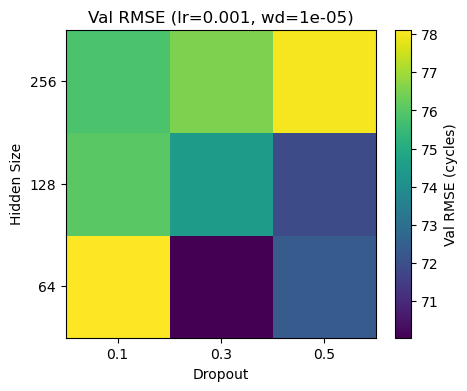

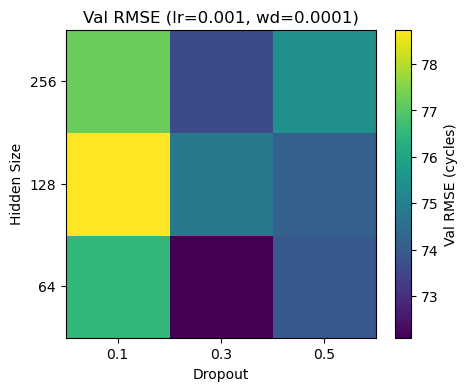

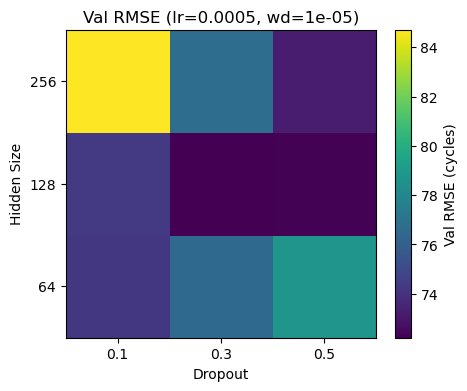

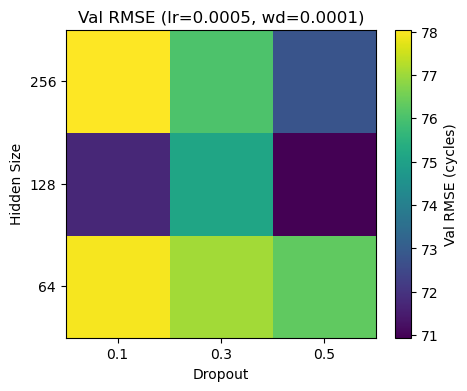

In [174]:
#Heatmap of Grid Search

lrs = [1e-3, 5e-4]
wds = [1e-5, 1e-4]

for lr in lrs:
    for wd in wds:
        sub = df_grid[(df_grid.lr == lr) & (df_grid.wd == wd)]
        if sub.empty: 
            continue
        pivot = sub.pivot(index='hidden', columns='dropout', values='val_rmse')
        plt.figure(figsize=(5,4))
        plt.title(f"Val RMSE (lr={lr}, wd={wd})")
        plt.imshow(pivot, origin='lower', aspect='auto')
        plt.xticks(np.arange(len(pivot.columns)), pivot.columns)
        plt.yticks(np.arange(len(pivot.index)), pivot.index)
        plt.xlabel("Dropout")
        plt.ylabel("Hidden Size")
        plt.colorbar(label="Val RMSE (cycles)")
        plt.show()


Epoch 01 | Train MAE: 120.0631 | Val MAE: 100.5873
Epoch 10 | Train MAE: 84.9653 | Val MAE: 80.4801
Epoch 20 | Train MAE: 72.2505 | Val MAE: 68.9528
Epoch 30 | Train MAE: 64.6703 | Val MAE: 74.7255
Epoch 40 | Train MAE: 58.6613 | Val MAE: 63.1456
Epoch 50 | Train MAE: 51.8299 | Val MAE: 51.1067
Epoch 60 | Train MAE: 49.0966 | Val MAE: 52.5624


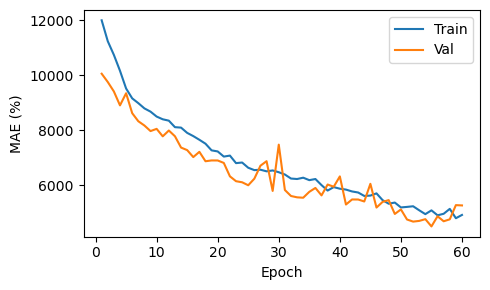


Test MAE: 51.7 cycles (29.0%)


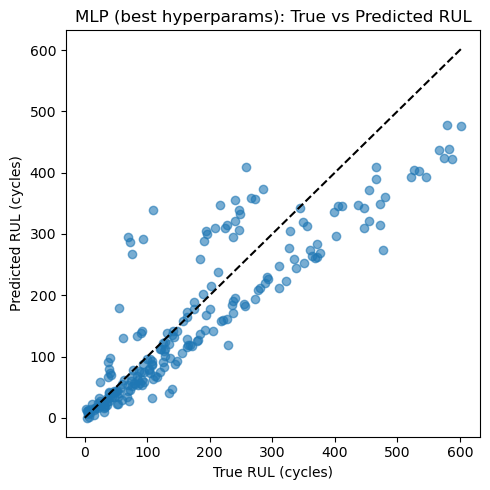

In [199]:
#MLP RUL with best hyperparameters

X = df_rul_ext[feature_cols_ext].values.astype(np.float32)
y = df_rul_ext['rul'].values.astype(np.float32)
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.20, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42)

train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
val_ds = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
test_ds = TensorDataset(torch.tensor(X_te), torch.tensor(y_te))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds,batch_size=64, shuffle=False)

model_best = MLP_RUL(in_dim=len(feature_cols_ext), hidden=256, drop=0.1).to(device)
optimizer = optim.AdamW(model_best.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.L1Loss()

train_maes, val_maes = [], []

for epoch in range(1, 61):

    model_best.train()
    total, count = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model_best(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * xb.size(0)
        count += xb.size(0)
    train_mae = total / count
    train_maes.append(train_mae)

    model_best.eval()
    total, count = 0.0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            total += criterion(model_best(xb), yb).item() * xb.size(0)
            count += xb.size(0)
    val_mae = total / count
    val_maes.append(val_mae)

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:02d} | Train MAE: {train_mae:.4f} | Val MAE: {val_mae:.4f}")

model_best.eval()
preds, trues = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds.append(model_best(xb).cpu().numpy())
        trues.append(yb.numpy())
y_pred = np.concatenate(preds)
y_true = np.concatenate(trues)

test_mae = mean_absolute_error(y_true, y_pred)
test_mae_pct = test_mae / y_true.mean() * 100
print(f"\nTest MAE: {test_mae:.1f} cycles ({test_mae_pct:.1f}%)")

plt.figure(figsize=(5,5))
plt.scatter(y_true, y_pred, alpha=0.6)
lims = [0, max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'k--')
plt.xlabel("True RUL (cycles)")
plt.ylabel("Predicted RUL (cycles)")
plt.title("MLP (best hyperparams): True vs Predicted RUL")
plt.tight_layout()
plt.show()

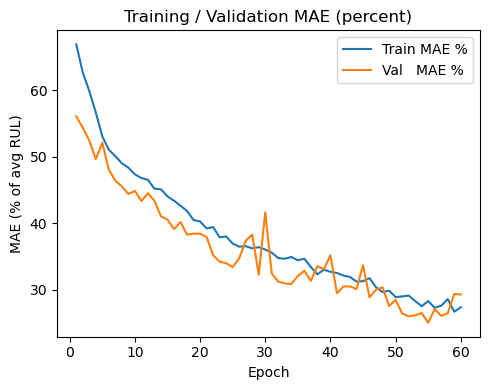

In [203]:
mean_rul = np.mean(y_tr)  
epochs = np.arange(1, len(train_maes) + 1)
train_pct = np.array(train_maes) / mean_rul * 100
val_pct = np.array(val_maes) / mean_rul * 100

plt.figure(figsize=(5,4))
plt.plot(epochs, train_pct, label="Train MAE %")
plt.plot(epochs, val_pct, label="Val MAE %")
plt.xlabel("Epoch")
plt.ylabel("MAE (% of avg RUL)")
plt.title("Training / Validation MAE (percent)")
plt.legend()
plt.tight_layout()
plt.show()

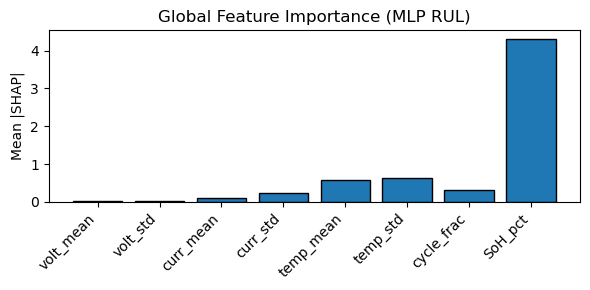

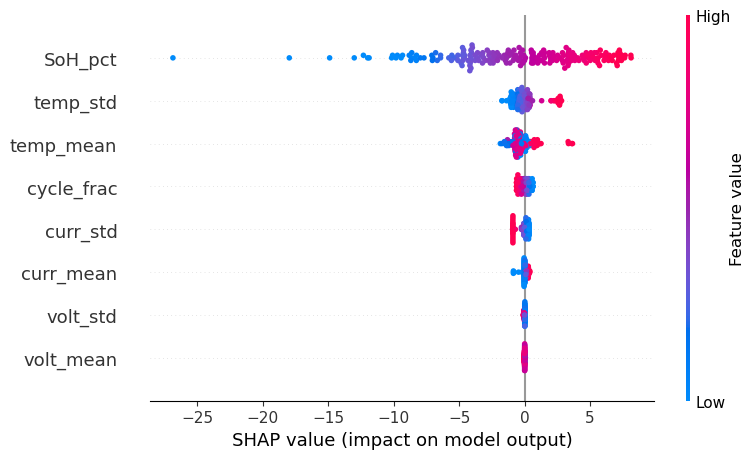

In [210]:
#SHAP Feature Importance, how much change in feature changes the prediction
val_tensor = torch.tensor(X_val, dtype=torch.float32, device=device)
raw_shap = explainer.shap_values(val_tensor)
shap_vals = raw_shap[0] if isinstance(raw_shap, list) else raw_shap

plt.figure(figsize=(6,3))
feat_names = feature_cols
mean_abs = np.mean(np.abs(shap_vals), axis=0)
plt.bar(feat_names, mean_abs, edgecolor='k')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean |SHAP|")
plt.title("Global Feature Importance (MLP RUL)")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_vals, X_val, feature_names=feat_names, plot_type="dot")



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



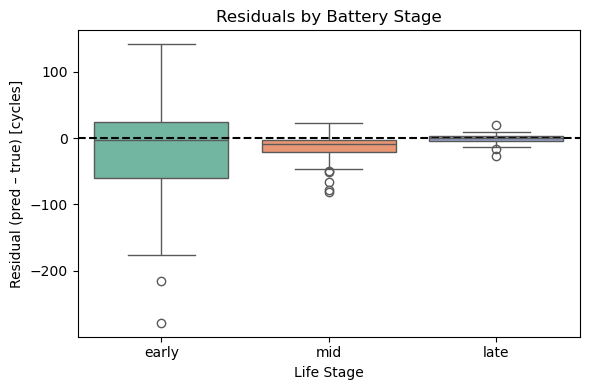

In [213]:
plt.figure(figsize=(6,4))
sns.boxplot(x='stage', y='resid', data=df_res, palette='Set2')
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Life Stage")
plt.ylabel("Residual (pred – true) [cycles]")
plt.title("Residuals by Battery Stage")
plt.tight_layout()
plt.show()